In [1]:
import matplotlib.pyplot as plt

from neural_astar.planner import VanillaAstar
from neural_astar.utils.data_maps import create_dataloader
from neural_astar.utils.training import load_from_ptl_checkpoint

/home/mastrelli/neural-astar/.venv/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


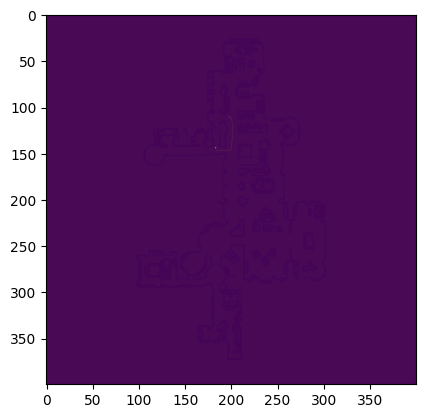

In [2]:
from neural_astar.utils.data_maps import visualize_results_voronoi
from neural_astar.utils.data import visualize_results
from neural_astar.planner.astar import NeuralAstar

dataloader = create_dataloader("/home/mastrelli/neural-astar/src/maps_npz", "train_ds.npz", 2)
map_designs, start_maps, goal_maps, opt_trajs= next(iter(dataloader))
plt.imshow(map_designs[0][0], alpha=0.6)
plt.imshow(opt_trajs[0][0], alpha=0.6)
plt.imshow(start_maps[0][0], alpha=0.7)
plt.imshow(goal_maps[0][0], alpha=0.7)

torch.Size([2, 1, 400, 400])


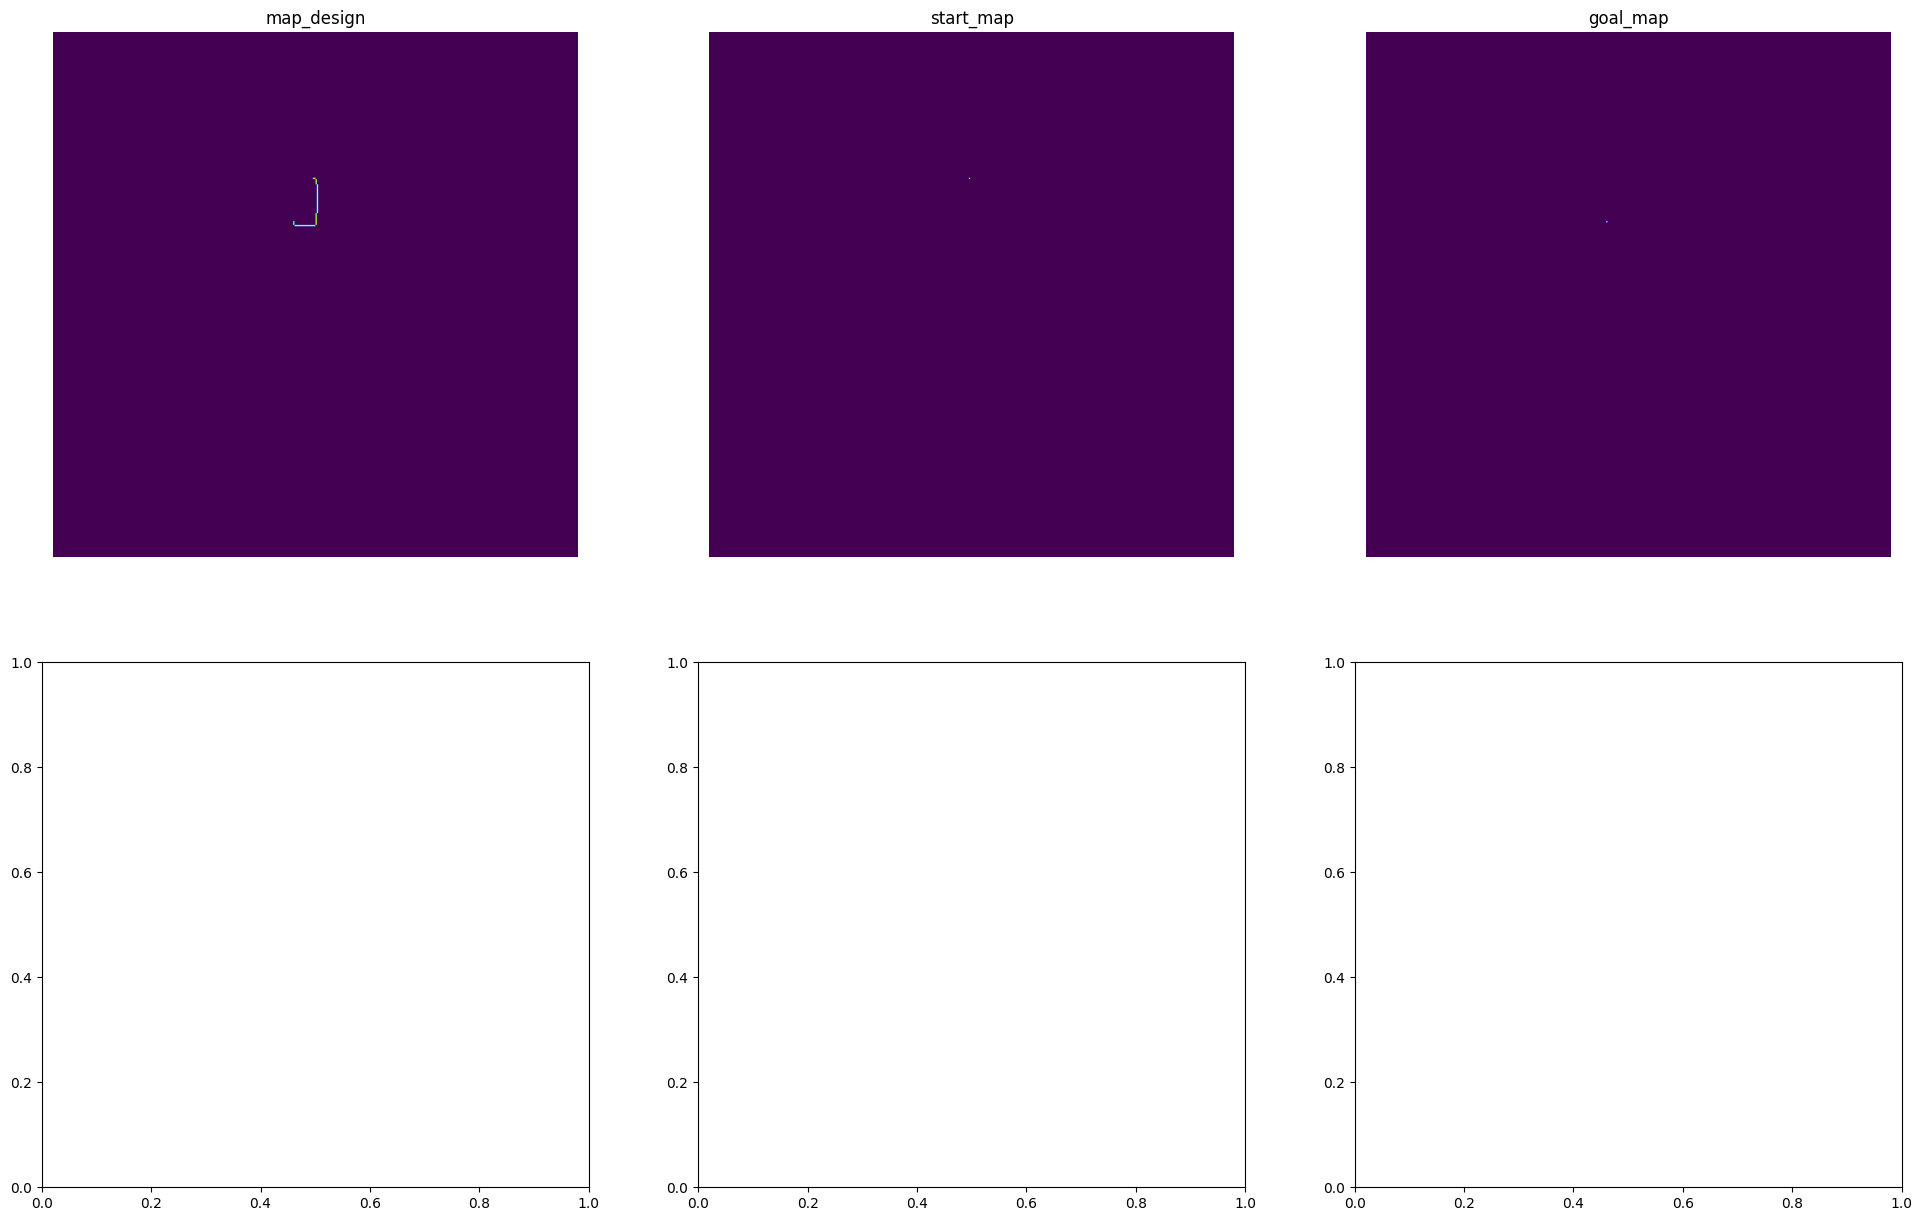

In [3]:
print(start_maps.shape)

fig, axes = plt.subplots(2, 3, figsize=[24, 15])
for i in range(1):
    axes[i, 0].imshow(opt_trajs.numpy()[i, 0])
    axes[i, 0].set_title("map_design")
    axes[i, 0].axis("off")
    axes[i, 1].imshow(start_maps.numpy()[i, 0])
    axes[i, 1].set_title("start_map")
    axes[i, 1].axis("off")
    axes[i, 2].imshow(goal_maps.numpy()[i, 0])
    axes[i, 2].set_title("goal_map")
    axes[i, 2].axis("off")

In [4]:
va = NeuralAstar(encoder_depth=3).to('cuda')
va.load_state_dict(load_from_ptl_checkpoint("/home/mastrelli/neural-astar/model/voronoi/maps_npz/lightning_logs/trainMaps1"))
va.eval()
out_g = va(map_designs.to('cuda'), start_maps.to('cuda'), goal_maps.to('cuda'))
#out_g = va(image_tensor.to('cuda'), start_maps_.to('cuda'), goal_maps_.to('cuda'))

load /home/mastrelli/neural-astar/model/voronoi/maps_npz/lightning_logs/trainMaps1/checkpoints/epoch=9-step=460.ckpt


/home/mastrelli/neural-astar/.venv/lib/python3.8/site-packages/torch/functional.py:478: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at  ../aten/src/ATen/native/TensorShape.cpp:2894.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


Text(0.5, 1.0, 'Ground truth')

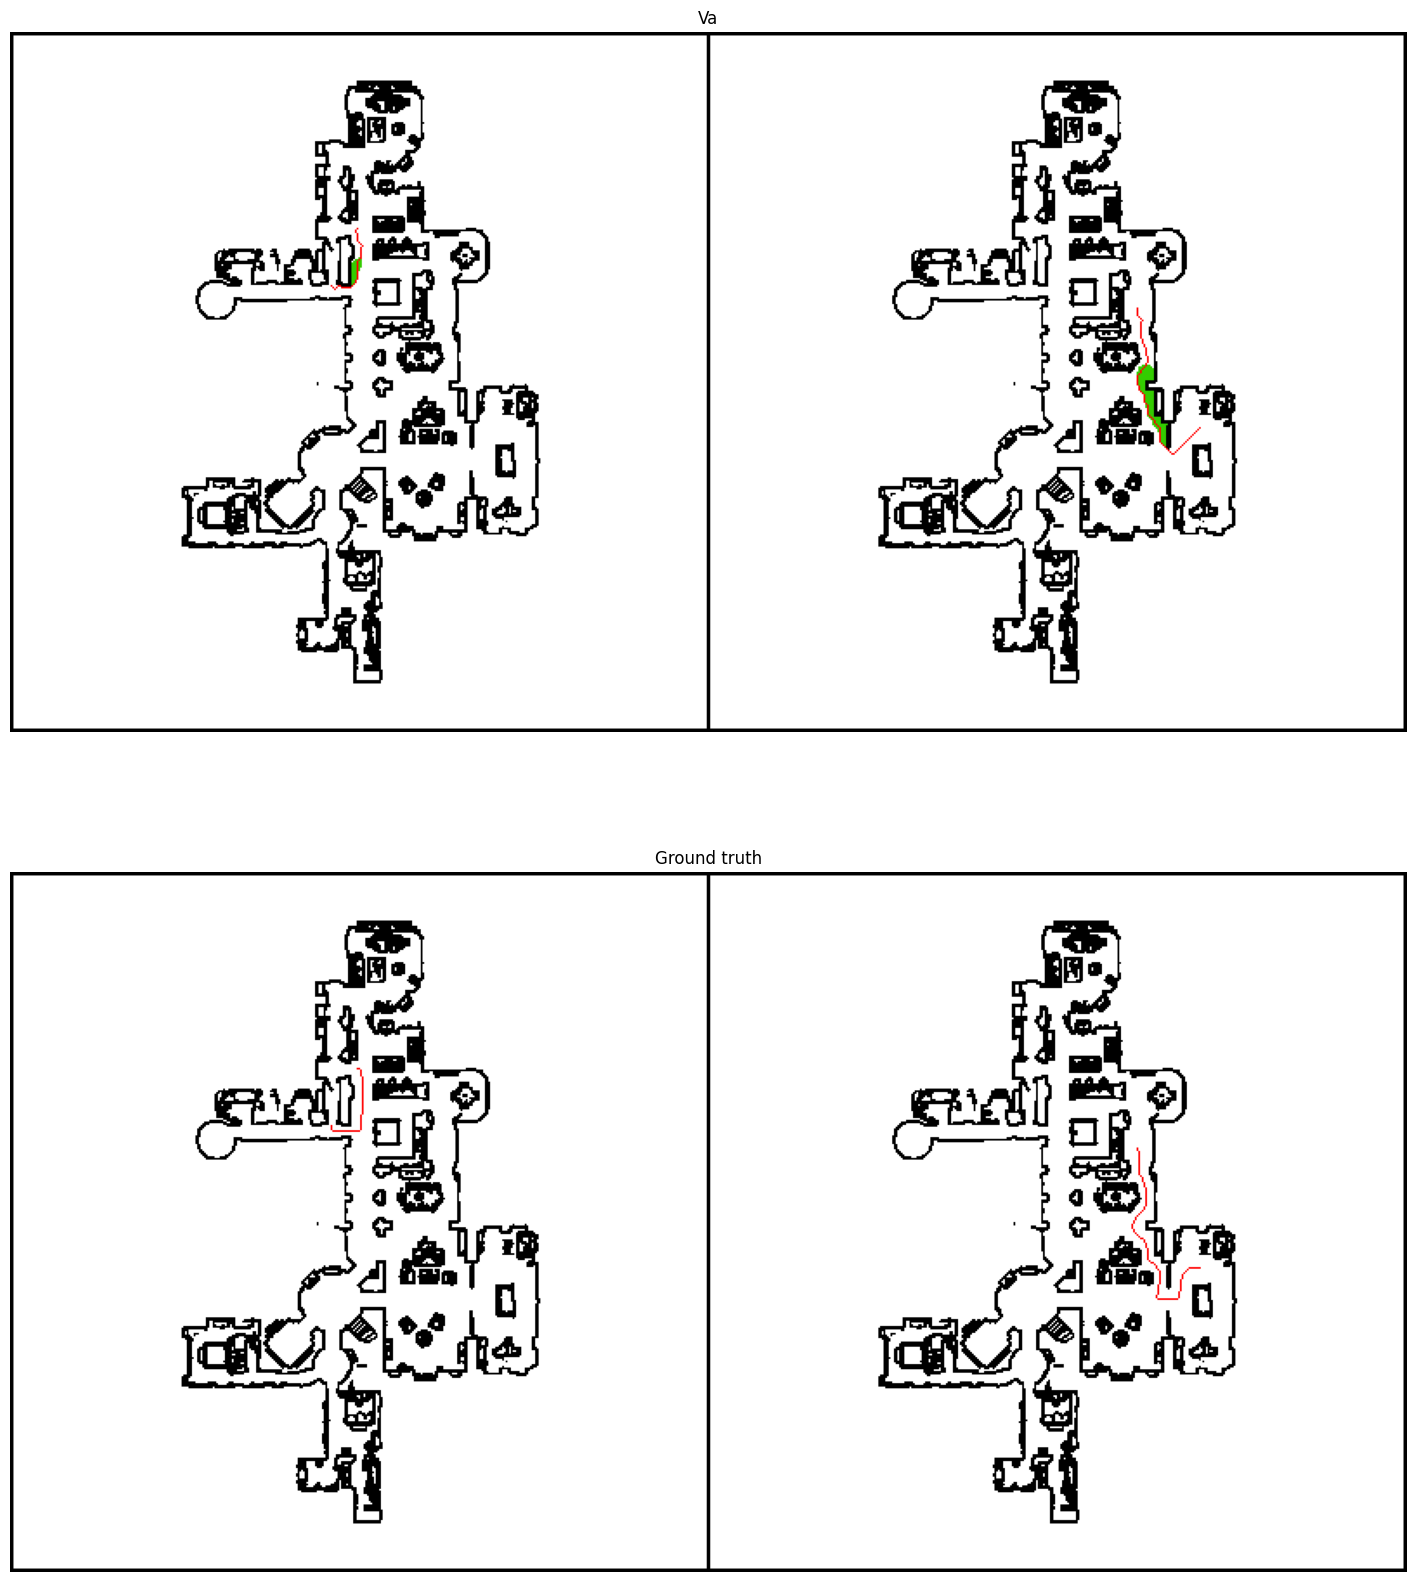

In [5]:
fig, axes = plt.subplots(2, 1, figsize=[20, 20])



axes[0].imshow(visualize_results(map_designs, out_g))
axes[0].set_title("Va")
axes[0].axis("off")
axes[1].imshow(visualize_results_voronoi(map_designs, opt_trajs))
axes[1].axis("off")
axes[1].set_title("Ground truth")

In [6]:
import torch

parents = torch.rand(5, 160000)
loc = torch.rand(5).type(torch.long)
parents[0, loc]

tensor([0.6880, 0.6880, 0.6880, 0.6880, 0.6880])